# Roadway Geometry — Curves and Sight Distance

An invented two-lane rural collector, 45 mph design speed: a crest curve
over a ridge, a sag under it, and a horizontal curve around a barn.  All
from `civilpy.transportation` (`roadway` for the AASHTO Green Book criteria,
`curves` for the geometry).

## Stopping sight distance

Everything starts with SSD (Green Book 3-2 / 3-3): brake-reaction distance
plus braking distance, with grade correction where it matters:

In [1]:
from civilpy.transportation import roadway as rd

v = 45.0  # design speed, mph
ssd_level = rd.stopping_sight_distance(v)
ssd_down = rd.stopping_sight_distance(v, grade=-0.04)
print(f"SSD level        = {ssd_level:.0f} ft")
print(f"SSD on -4% grade = {ssd_down:.0f} ft")
print(f"decision sight distance (maneuver A, stop on rural road) = "
      f"{rd.decision_sight_distance(v, 'A'):.0f} ft")

SSD level        = 359 ft
SSD on -4% grade = 385 ft
decision sight distance (maneuver A, stop on rural road) = 393 ft


## Crest vertical curve

The profile climbs at +3.2% and falls at -2.4% over the ridge (A = 5.6).
The curve must be long enough that a 3.5-ft eye can see a 2-ft object over
the summit within the SSD:

In [2]:
a = abs(-2.4 - 3.2)
l_min = rd.crest_curve_length(a, ssd_level)
k = l_min / a
print(f"minimum crest curve length L = {l_min:.0f} ft  (K = {k:.0f})")

# round the design up to an even station
L = 500.0
print(f"use L = {L:.0f} ft -> K = {L/a:.0f}")

minimum crest curve length L = 333 ft  (K = 60)
use L = 500 ft -> K = 89


BVC 43+00.00  elev 864.40
EVC 48+00.00  elev 866.40
high point at 45+85.71, elev 868.97 ft


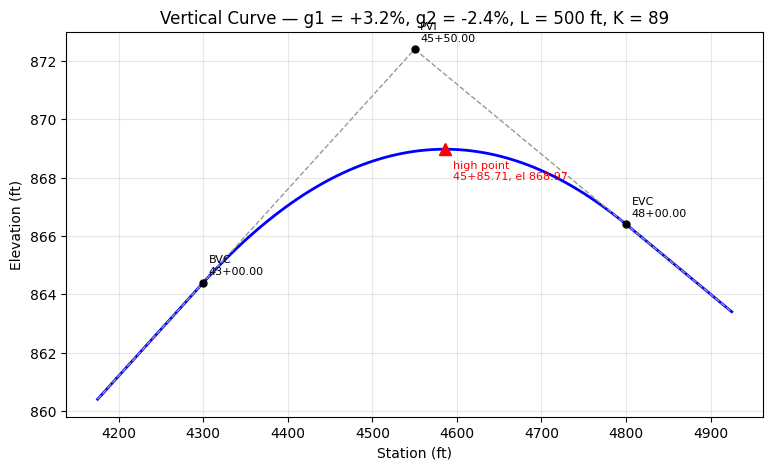

In [3]:
from civilpy.transportation.curves import VerticalCurve, station_str

crest = VerticalCurve(
    g1_pct=3.2, g2_pct=-2.4, length_ft=L,
    pvi_station_ft=4550.0, pvi_elevation_ft=872.4,
)
hp = crest.high_low_point()
print(f"BVC {station_str(crest.bvc_station)}  elev {crest.bvc_elevation:.2f}")
print(f"EVC {station_str(crest.evc_station)}  elev {crest.evc_elevation:.2f}")
print(f"high point at {station_str(hp[0])}, elev {hp[1]:.2f} ft")
crest.plot();

## Sag vertical curve

Where the road ducks back down (-2.4% to +2.0%), the sag criterion is
headlight reach at night:

In [4]:
a_sag = abs(2.0 - (-2.4))
l_sag = rd.sag_curve_length(a_sag, ssd_level)
print(f"minimum sag curve length L = {l_sag:.0f} ft  (K = {l_sag/a_sag:.0f})")
print(f"from a design table K = 79: L = {rd.vertical_curve_length_from_k(79, a_sag):.0f} ft")

minimum sag curve length L = 342 ft  (K = 78)
from a design table K = 79: L = 348 ft


## Horizontal curve

The alignment deflects 38 degrees around the barn.  Point-mass first — what
radius does 45 mph demand with e_max = 8% — then the curve geometry and the
stakeout table:

minimum radius at 45 mph: 587 ft
T = 275.5 ft   L = 530.6 ft   C = 520.9 ft   E = 46.1 ft
D (arc definition) = 7.16 deg
PC 65+49.54   PT 70+80.12
friction demand at 45 mph, e = 0.08: f = 0.089


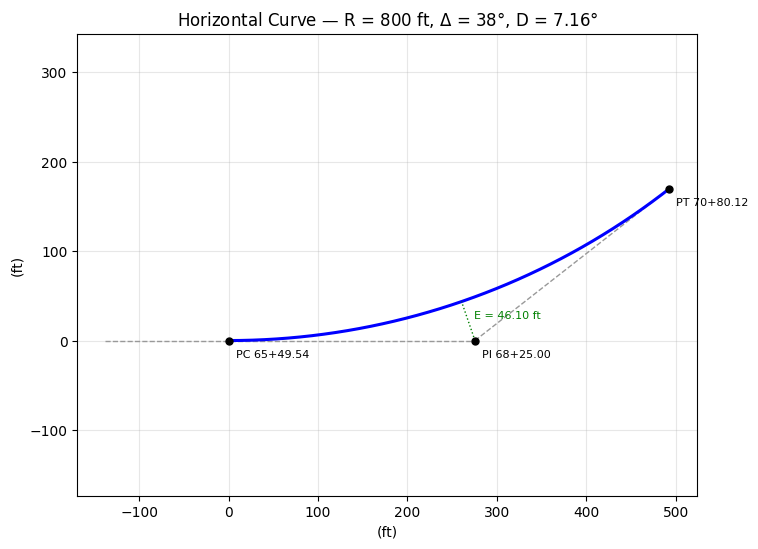

In [5]:
from civilpy.transportation.curves import HorizontalCurve

r_min = HorizontalCurve.min_radius(speed_mph=v, e_max=0.08, f_max=0.15)
print(f"minimum radius at {v:.0f} mph: {r_min:.0f} ft")

hc = HorizontalCurve(radius_ft=800.0, delta_deg=38.0, pi_station_ft=6825.0)
print(
    f"T = {hc.tangent_ft:.1f} ft   L = {hc.length_ft:.1f} ft   "
    f"C = {hc.chord_ft:.1f} ft   E = {hc.external_ft:.1f} ft"
)
print(f"D (arc definition) = {hc.degree_of_curve_deg:.2f} deg")
print(f"PC {station_str(hc.pc_station)}   PT {station_str(hc.pt_station)}")
print(
    f"friction demand at 45 mph, e = 0.08: f = {hc.side_friction_demand(v, 0.08):.3f}"
)
hc.plot()

## Superelevation transition

Rotating the two 12-ft lanes to 8% superelevation (Green Book 3.9.8):

In [6]:
bw = rd.runoff_adjustment_factor(lanes_rotated=2)
lr = rd.superelevation_runoff_length(
    superelevation=0.08, lane_width=12.0, lanes_rotated=2,
    max_relative_gradient=0.0054,   # Green Book Table 3-15 at 45 mph (0.54%)
    adjustment_factor=bw,
)
lt = rd.tangent_runout_length(
    runoff_length=lr, superelevation=0.08, normal_cross_slope=0.02,
)
print(f"adjustment factor bw = {bw:.2f}")
print(f"superelevation runoff  Lr = {lr:.0f} ft")
print(f"tangent runout         Lt = {lt:.0f} ft")

adjustment factor bw = 0.75
superelevation runoff  Lr = 267 ft
tangent runout         Lt = 67 ft


## Guardrail length of need

A fixed object (the barn corner) sits 18 ft off the travelled way; the
barrier flares at 15:1.  Roadside Design Guide length-of-need
(``flare_rate`` is the lateral-per-longitudinal ratio b/a, so a 15:1
flare is 1/15):

In [7]:
lon = rd.barrier_length_of_need(
    runout_length=360.0, lateral_extent=18.0,
    barrier_offset=6.0, flare_rate=1 / 15.0,
)
print(f"length of need = {lon:.0f} ft of barrier upstream of the hazard")

length of need = 106 ft of barrier upstream of the hazard
